<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/Homework2026/2026/HW/HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 4: Solving PDEs in Physics — Heat, Fields, and Beams (42 pts)

## Learning Outcomes

- Use **Python type annotations** for function signatures and return values
- Solve differential equations using **scipy** (`solve_ivp`, `solve_bvp`, `spsolve`)
- Understand the **finite difference method** as the foundation behind these solvers
- Validate numerical solutions against analytical limits
- Create **publication-quality plots** using `rcParams` for consistent styling
- Submit homework via **fork and pull request**
- Work with **AI code review** (GitHub Copilot) as part of a professional PR workflow

## Development Environment

You have two options for working on this homework:

### Option A: GitHub Codespaces (recommended)

**GitHub Codespaces** gives you a cloud-based VS Code environment with Python, Jupyter, and all dependencies pre-installed — no setup needed.

1. **Fork the repository**: Go to [github.com/ubsuny/PHY386](https://github.com/ubsuny/PHY386) → click **"Fork"**
2. **Sync your fork**: On your fork's page, click **"Sync fork"** → **"Update branch"**
3. **Open a Codespace**: Green **"Code"** button → **"Codespaces"** tab → **"Create codespace on Homework2026"**
4. **Create your branch**: In the terminal: `git checkout -b yourname-hw4`
5. Work on `2026/HW/yourname/HW4.ipynb` using the built-in Jupyter extension

### Option B: Google Colab

Click the **"Open in Colab"** badge at the top of this notebook. When done, use **File → Save a copy to GitHub** to push to your fork.

---

**Either way, you must submit via the fork workflow** (see Submission section at the end).

## Python Type Annotations

In HW2 you learned to write **docstrings**. Now we add **type annotations** — hints that specify what types your function expects and returns.

### Important: Type Annotations Are NOT Checked by Python

Unlike languages such as C++ or Java, Python **does not enforce type annotations at runtime**. If you write `def f(x: int)` and call `f("hello")`, Python will happily run it — no error.

So why bother? Because type annotations are checked by **separate tools**:

- **Your editor**: VS Code (via Pylance) and Colab (via Pyright) can underline type errors in real time
- **Static analysis tools**: `mypy` checks types without running the code
- **Code review**: In this homework, **GitHub Copilot** will review your PR and flag type annotation issues
- **Your collaborators**: Type annotations serve as documentation — anyone reading your code instantly knows what a function expects

This is how type annotations work in professional Python code: they're a contract between the programmer and the tools, not between the programmer and the interpreter.

### Basic Syntax

```python
def function_name(param1: type1, param2: type2) -> return_type:
    """Docstring here."""
    ...
```

### Example: Type Annotations + NumPy Docstring

```python
import numpy as np

def kinetic_energy(mass: float, velocity: np.ndarray) -> np.ndarray:
    """Compute kinetic energy for each velocity.

    Parameters
    ----------
    mass : float
        Mass of the object (kg).
    velocity : np.ndarray
        Array of velocities (m/s).

    Returns
    -------
    np.ndarray
        Kinetic energy for each velocity (J).
    """
    return 0.5 * mass * velocity**2
```

### Common Type Patterns

```python
# Single return
def f(x: float) -> float: ...

# Array in, array out
def g(data: np.ndarray) -> np.ndarray: ...

# Multiple returns
def h(x: np.ndarray) -> tuple[np.ndarray, float]: ...

# Optional with default
def k(x: float, tol: float = 1e-6) -> float: ...
```

### How Type Checking Works in This Homework

1. **While you code**: Enable type checking in your editor
   - **VS Code / Codespaces**: Already enabled by the devcontainer settings (Pylance "basic" mode)
   - **Colab**: Tools → Settings → Editor → Code diagnostics → "Syntax and type checking"
2. **When you submit your PR**: A GitHub Action runs `mypy` on your notebook and reports type errors
3. **When Copilot reviews**: It flags missing or incorrect type annotations

**Requirement:** All functions in this homework must have **both** type annotations **and** NumPy-style docstrings.

## Background: The Finite Difference Method

Many physics problems reduce to partial differential equations (PDEs) that can't be solved analytically. The **finite difference method** approximates derivatives on a discrete grid.

### Discretizing Derivatives

For a function $f(x)$ on a grid with spacing $\Delta x$:

**First derivative** (central difference):
$$f'(x) \approx \frac{f(x + \Delta x) - f(x - \Delta x)}{2 \Delta x}$$

**Second derivative**:
$$f''(x) \approx \frac{f(x + \Delta x) - 2f(x) + f(x - \Delta x)}{\Delta x^2}$$

### From PDE to ODE System

The key idea: discretize in **space** to get a system of **ordinary** differential equations in **time**, then let scipy's ODE solvers handle the time integration.

For the heat equation $\partial T / \partial t = \alpha \, \partial^2 T / \partial x^2$, discretizing in space gives:

$$\frac{dT_i}{dt} = \frac{\alpha}{\Delta x^2} \left( T_{i+1} - 2T_i + T_{i-1} \right)$$

This is just a system of coupled ODEs — one for each grid point $i$. We can write it as $d\vec{T}/dt = f(t, \vec{T})$ and hand it to `scipy.integrate.solve_ivp()`.

### Why Use scipy?

Writing your own time stepper (like forward Euler) requires worrying about stability conditions ($\alpha \Delta t / \Delta x^2 < 1/2$). scipy's solvers handle this automatically — they adapt the time step to maintain accuracy and stability.

## Worked Example: 1D Heat Equation on a Metal Rod

A metal rod of length $L$ is held at temperature $T_{\text{hot}}$ on the left end and $T_{\text{cold}}$ on the right end. The rod starts at a uniform temperature $T_0$.

The **heat equation** describes how temperature evolves:

$$\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}$$

where $\alpha$ is the thermal diffusivity (m²/s). For copper, $\alpha \approx 1.11 \times 10^{-4}$ m²/s.

**Boundary conditions**: $T(0, t) = T_{\text{hot}}$, $T(L, t) = T_{\text{cold}}$

**Initial condition**: $T(x, 0) = T_0$ (uniform)

**Analytical steady state**: When $\partial T / \partial t = 0$, we get $T'' = 0$, so $T(x) = T_{\text{hot}} + (T_{\text{cold}} - T_{\text{hot}}) \frac{x}{L}$ — a linear profile.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, solve_bvp
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# --- Publication-quality plot settings using rcParams ---
#
# matplotlib.rcParams is a global dictionary that controls the default
# appearance of ALL plots created after this cell runs. Setting them once
# here means you don't have to repeat font sizes, tick styles, etc. in
# every single plot.
#
# Why this matters:
#   - Physics journals require consistent, readable figures
#   - Setting rcParams once ensures uniform style across your entire notebook
#   - You can still override any setting for a specific plot if needed
#
# Common rcParams you'll use:
#   'font.size'          — base font size for all text (default: 10)
#   'axes.labelsize'     — axis label font size (e.g., "Position (m)")
#   'axes.titlesize'     — plot title font size
#   'xtick.labelsize'    — numbers on x-axis
#   'legend.fontsize'    — text inside legends
#   'xtick.direction'    — 'in' puts tick marks inside the plot frame
#                          (standard in physics publications)
#   'xtick.top'          — True adds ticks to the top axis too
#   'figure.figsize'     — default figure size in inches (width, height)
#
# See all options: https://matplotlib.org/stable/users/explain/customizing.html

plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'xtick.direction': 'in',       # ticks point inward (physics convention)
    'ytick.direction': 'in',
    'xtick.top': True,             # show ticks on top and right axes
    'ytick.right': True,
    'figure.figsize': (6, 4),      # default figure size
})

In [2]:
def heat_rhs(t: float, T_interior: np.ndarray, alpha: float, dx: float,
             T_left: float, T_right: float) -> np.ndarray:
    """Right-hand side of the 1D heat equation for interior grid points.

    Computes dT/dt = alpha * d^2T/dx^2 using central finite differences.
    Boundary values are fixed and passed as parameters.

    Parameters
    ----------
    t : float
        Current time (s). Not used, but required by solve_ivp.
    T_interior : np.ndarray
        Temperature at interior grid points (K). Shape (N-2,).
    alpha : float
        Thermal diffusivity (m^2/s).
    dx : float
        Grid spacing (m).
    T_left : float
        Fixed temperature at left boundary (K).
    T_right : float
        Fixed temperature at right boundary (K).

    Returns
    -------
    np.ndarray
        Time derivative dT/dt at interior points (K/s). Shape (N-2,).
    """
    # Reconstruct full array with boundaries
    T_full = np.concatenate([[T_left], T_interior, [T_right]])

    # Central difference for d^2T/dx^2 at interior points
    d2T = (T_full[2:] - 2 * T_full[1:-1] + T_full[:-2]) / dx**2

    return alpha * d2T


# --- Physical parameters ---
L = 0.5           # rod length (m)
alpha = 1.11e-4   # thermal diffusivity of copper (m^2/s)
T_hot = 373.0     # left end: boiling water (K)
T_cold = 293.0    # right end: room temperature (K)
T_init = 293.0    # initial uniform temperature (K)

# --- Spatial grid ---
N = 50
x = np.linspace(0, L, N)
dx = x[1] - x[0]

# --- Initial condition (interior points only) ---
T0_interior = np.full(N - 2, T_init)

# --- Solve with scipy ---
t_end = 500.0  # seconds
t_eval = [0, 1, 5, 20, 100, 500]  # times to record

sol = solve_ivp(
    fun=lambda t, T: heat_rhs(t, T, alpha, dx, T_hot, T_cold),
    t_span=(0, t_end),
    y0=T0_interior,
    t_eval=t_eval,
    method='RK45'
)

print(f"Solver status: {sol.message}")
print(f"Grid points: {N}, dx = {dx*100:.2f} cm")
print(f"Time steps used by solver: {sol.t.size}")

Solver status: The solver successfully reached the end of the integration interval.
Grid points: 50, dx = 1.02 cm
Time steps used by solver: 6


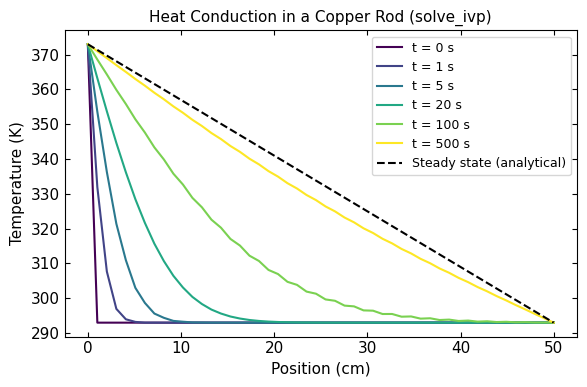

In [3]:
# --- Plot temperature profiles at different times ---
# Note: figsize, tick direction, and font sizes are set globally by rcParams above.
# You only need to specify them here if you want to override the defaults.

fig, ax = plt.subplots()  # uses rcParams default figsize=(6, 4)

colors = plt.cm.viridis(np.linspace(0, 1, len(sol.t)))
for i, t in enumerate(sol.t):
    # Reconstruct full profile with boundaries
    T_full = np.concatenate([[T_hot], sol.y[:, i], [T_cold]])
    ax.plot(x * 100, T_full, color=colors[i], label=f't = {t:.0f} s')

# Analytical steady state
T_steady = T_hot + (T_cold - T_hot) * x / L
ax.plot(x * 100, T_steady, 'k--', linewidth=1.5, label='Steady state (analytical)')

ax.set_xlabel('Position (cm)')
ax.set_ylabel('Temperature (K)')
ax.set_title('Heat Conduction in a Copper Rod (solve_ivp)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The numerical solution converges to the analytical steady-state linear profile. Notice that we didn't need to worry about stability conditions — `solve_ivp` handles the time stepping automatically.

---

## Step 0: Choose Your PDE Problem

**BEFORE YOU START:** Claim your problem using GitHub Issues (same process as HW3).

### How to Claim (First Come, First Served, max 3 students per problem):

1. Go to the **HW4 Problem Selection Issue** (link will be posted on the repository)
2. Comment with: `I'm claiming Problem [A/B/C]`
3. Create your own tracking issue with title: `HW4 - Problem [A/B/C] - @yourusername`

---

### Available Problems

| Problem | Equation | Physics | scipy Tool | Plotting |
|---------|----------|---------|------------|----------|
| **A: Electrostatics** | $\nabla^2 V = 0$ (Laplace) | Electric potential between conductors | `spsolve` (sparse linear system) | 2D contour + quiver |
| **B: Heat with Source** | $\partial T/\partial t = \alpha \, T'' + S(x)$ | Resistive heating in a wire | `solve_ivp` (time integration) | Multi-time profiles + heatmap |
| **C: Beam Deflection** | $EI \, y'''' = w(x)$ | Cantilever under load | `solve_bvp` (boundary value problem) | Deflection curves + parameter study |

Each problem is described in its own section below. **Complete only the one you claimed.**

---

**Once you've claimed your problem, scroll to the corresponding section.**

## Problem A: 2D Electrostatics — Laplace Equation (22 points)

### Background

The electric potential $V(x, y)$ in a charge-free region satisfies **Laplace's equation**:

$$\nabla^2 V = \frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} = 0$$

This appears everywhere in electrostatics (Griffiths Ch. 3). Given voltages on the boundaries (conductors), we solve for the potential everywhere inside.

### Method: From PDE to Linear System with `spsolve`

Just as the worked example turned the heat equation into an ODE system for `solve_ivp`, here we turn Laplace's equation into a **linear system** $A\vec{V} = \vec{b}$ for `spsolve`.

Discretizing on a 2D grid, each interior point gives one equation:

$$V_{i+1,j} + V_{i-1,j} + V_{i,j+1} + V_{i,j-1} - 4 V_{i,j} = 0$$

This is $N_{\text{interior}}$ equations in $N_{\text{interior}}$ unknowns — a linear system. The matrix $A$ is **sparse** (each row has at most 5 nonzero entries out of potentially thousands of columns), so we use `scipy.sparse.linalg.spsolve()` which is optimized for this.

### How to Build the Sparse System

The tricky part is mapping 2D grid indices $(i, j)$ to a 1D vector index $k$. Here's a helper:

```python
# Map 2D grid point (i, j) to 1D index k
def grid_to_index(i: int, j: int, Nx: int) -> int:
    return i * Nx + j
```

For each interior point $(i, j)$:
- **If it's a boundary point**: Set row $k$ to $A[k, k] = 1$ and $b[k] = V_{\text{boundary}}$
- **If it's an interior point**: Set $A[k, k] = -4$ and $A[k, \text{neighbors}] = 1$, $b[k] = 0$

Use `scipy.sparse.lil_matrix` to build $A$ (it's efficient for row-by-row construction), then solve with `spsolve(A.tocsr(), b)`.

### Geometry

Square domain (1 m × 1 m):
- **Top boundary**: $V = 100$ V
- **Bottom, left, right boundaries**: $V = 0$ V

---

### Tasks

**Task A.1 (8 points):** Write a function that builds the sparse linear system and solves it:

```python
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

def solve_laplace(
    Nx: int,
    Ny: int,
    V_top: float,
    V_bottom: float,
    V_left: float,
    V_right: float
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
```

- Loop over all grid points. For boundary points, set $A[k,k]=1$, $b[k]=V_{\text{boundary}}$. For interior points, set the 5-point stencil.
- Solve with `spsolve(A.tocsr(), b)` and `reshape()` the result to 2D
- Returns: `(x_grid, y_grid, V_2d)` — coordinate arrays from `np.meshgrid` and the 2D potential
- Must have type annotations and docstring

**Task A.2 (6 points):** Solve for the geometry above with a 50×50 grid. Create a **2D filled contour plot** of the potential:
- Use `RdBu` colormap (diverging — appropriate for potential)
- Include a colorbar with label "V (Volts)"
- Label axes with units (m)
- Use `figsize=(6, 5)` to accommodate the colorbar

**Task A.3 (6 points):** Compute the electric field $\vec{E} = -\nabla V$ using `np.gradient()`.
- Create a figure with the potential contour **and** electric field arrows (`plt.quiver()`) overlaid
- Use a stride (e.g., every 5th point) so arrows don't overlap
- Normalize arrow lengths for clarity

**Task A.4 (2 points):** Reduce to the 1D limit: set all four boundaries to $V = 0$ except top = 100 V. For a tall, narrow domain (e.g., 5×50 grid), the center column should approach the analytical solution $V(y) = 100 \cdot y/L_y$. Plot both the numerical center-column profile and the analytical line on the same axes.

In [4]:
# Problem A: Your code here


## Problem B: 1D Heat Equation with Internal Source (22 points)

### Background

When a wire carries current, resistive heating generates heat internally. The temperature $T(x, t)$ along the wire satisfies:

$$\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2} + S(x)$$

where $\alpha$ is the thermal diffusivity (m²/s) and $S(x)$ is the heat source term (K/s). This also describes radioactive decay heating in geology and laser absorption in materials.

This is the same 1D heat equation from the worked example, but with an extra source term.

### Method: `solve_ivp` with Source

Just like the worked example, we discretize in space and use `solve_ivp()` for the time integration. The only difference is adding $S(x_i)$ to each grid point's right-hand side:

$$\frac{dT_i}{dt} = \frac{\alpha}{\Delta x^2} \left( T_{i+1} - 2T_i + T_{i-1} \right) + S(x_i)$$

### Setup

- Rod length: $L = 1$ m
- Thermal diffusivity: $\alpha = 0.01$ m²/s
- Boundary conditions: $T(0, t) = T(L, t) = 300$ K (both ends at room temperature)
- Initial condition: $T(x, 0) = 300$ K (uniform)
- Source: Gaussian centered at the middle of the rod

$$S(x) = S_0 \exp\left(-\frac{(x - L/2)^2}{2\sigma^2}\right)$$

with $S_0 = 50$ K/s and $\sigma = 0.1$ m.

### Analytical Steady State

At steady state ($\partial T / \partial t = 0$), the equation becomes:

$$\alpha \frac{d^2 T}{d x^2} = -S(x)$$

This is a boundary value problem you can solve with `solve_bvp` (rewriting $T'' = -S(x)/\alpha$ as two first-order ODEs: $y_0 = T$, $y_1 = T'$), or by double numerical integration using `scipy.integrate.cumulative_trapezoid`.

---

### Tasks

**Task B.1 (8 points):** Write the right-hand side function and solve using `solve_ivp`:

```python
def heat_with_source_rhs(
    t: float,
    T_interior: np.ndarray,
    alpha: float,
    dx: float,
    T_left: float,
    T_right: float,
    source: np.ndarray
) -> np.ndarray:
```

- Extends the worked example by adding `source` to the finite difference RHS
- Must have type annotations and docstring
- Call `solve_ivp()` to integrate from $t = 0$ to $t = 20$ s

**Task B.2 (6 points):** Create **two figures**:
1. Temperature profiles at $t = 0, 0.5, 2, 5, 20$ s on one figure (use a colormap for the line colors)
2. A $T(x, t)$ **heatmap** using `plt.pcolormesh()` with colorbar, labeled axes (x in m, t in s)

**Task B.3 (6 points):** Compare the steady-state numerical solution to an analytical/reference solution.
- Solve the steady-state BVP $T'' = -S(x)/\alpha$ with $T(0) = T(L) = 300$ K using `solve_bvp`
- Create a **2-panel figure** (`fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)`):
  - Top: numerical and analytical steady-state on same axes
  - Bottom: absolute error $|T_{\text{num}} - T_{\text{analytical}}|$

**Task B.4 (2 points):** What does the source profile look like? Plot $S(x)$ and the steady-state temperature on the same figure using **twin axes** (`ax2 = ax1.twinx()`). Label both y-axes clearly.

In [5]:
# Problem B: Your code here


## Problem C: Beam Deflection — Euler-Bernoulli Equation (22 points)

### Background

The deflection $y(x)$ of a beam under a distributed load $w(x)$ is governed by the **Euler-Bernoulli equation**:

$$EI \frac{d^4 y}{dx^4} = w(x)$$

where $E$ is Young's modulus (Pa) and $I$ is the second moment of area (m⁴). This equation appears in structural engineering, MEMS devices, and even DNA mechanics.

### Method: `solve_bvp`

This is a **boundary value problem** (BVP): we know conditions at both ends of the beam, not just the start. scipy's `solve_bvp()` is designed for exactly this.

To use it, rewrite the 4th-order ODE as a system of four 1st-order ODEs. Let:

$$y_0 = y, \quad y_1 = y', \quad y_2 = y'', \quad y_3 = y'''$$

Then:
$$\frac{d}{dx} \begin{pmatrix} y_0 \\ y_1 \\ y_2 \\ y_3 \end{pmatrix} = \begin{pmatrix} y_1 \\ y_2 \\ y_3 \\ w(x) / (EI) \end{pmatrix}$$

### Cantilever Beam

A cantilever is fixed at the left end ($x = 0$) and free at the right end ($x = L$):

```
    ████████████████████████████  ↓ w(x)
    ║                            
    ║  Fixed end          Free end
    x = 0                  x = L
```

**Boundary conditions:**
- Fixed end: $y(0) = 0$ (no deflection), $y'(0) = 0$ (no slope)
- Free end: $y''(L) = 0$ (no moment), $y'''(L) = 0$ (no shear)

### Parameters

- Beam length: $L = 1$ m
- Steel: $E = 200 \times 10^9$ Pa
- Rectangular cross-section ($b = 0.05$ m width, $h = 0.01$ m height): $I = bh^3/12$

---

### Tasks

**Task C.1 (8 points):** Write the ODE system and boundary condition functions, then solve with `solve_bvp`:

```python
def beam_ode(x: np.ndarray, y: np.ndarray, EI: float, w0: float) -> np.ndarray:
    """ODE system for Euler-Bernoulli beam."""
    ...

def beam_bc(ya: np.ndarray, yb: np.ndarray) -> np.ndarray:
    """Boundary conditions for cantilever beam."""
    ...
```

- `beam_ode` returns the 4-component derivative vector
- `beam_bc` returns the 4 residuals (should all be zero at solution)
- Solve using `solve_bvp()` with an initial guess (e.g., all zeros)
- Must have type annotations and docstrings

**Task C.2 (6 points):** Solve for **uniform load** $w_0 = -1000$ N/m (gravity).
- **Plot** the deflection curve
- Annotate the maximum deflection value and location with `plt.annotate()`
- Compare to the analytical solution:

$$y(x) = \frac{w_0}{24 EI}(x^4 - 4Lx^3 + 6L^2 x^2)$$

Plot both on the same axes.

**Task C.3 (6 points):** Solve for **point load** $F = -500$ N at the free end.
- Approximate as a narrow Gaussian load centered at $x = L$
- **Plot** deflection and compare to the analytical solution:

$$y(x) = \frac{F}{6EI}(3Lx^2 - x^3)$$

**Task C.4 (2 points):** Parameter study — solve for the uniform load with **3 different beam heights**: $h = 5, 10, 20$ mm (keeping width fixed). **Plot** all three on one figure with a legend showing the height.

In [6]:
# Problem C: Your code here


## Debugging Challenge (all students, 10 points)

The following function is supposed to solve the **1D wave equation** for a vibrating string:

$$\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}$$

where $u(x, t)$ is the displacement and $c$ is the wave speed. Both ends are fixed: $u(0,t) = u(L,t) = 0$.

**The code below has 4 bugs** — physics errors, coding errors, and type annotation errors. Your job is to find and fix them.

/tmp/ipykernel_10436/3064643307.py:47: RuntimeWarning: overflow encountered in scalar add
  u_new[i] = 2*u[i] - u_old[i] + C2 * (u[i+1] + 2*u[i] + u[i-1])  # BUG somewhere here
/tmp/ipykernel_10436/3064643307.py:47: RuntimeWarning: overflow encountered in scalar multiply
  u_new[i] = 2*u[i] - u_old[i] + C2 * (u[i+1] + 2*u[i] + u[i-1])  # BUG somewhere here
/tmp/ipykernel_10436/3064643307.py:47: RuntimeWarning: invalid value encountered in scalar subtract
  u_new[i] = 2*u[i] - u_old[i] + C2 * (u[i+1] + 2*u[i] + u[i-1])  # BUG somewhere here


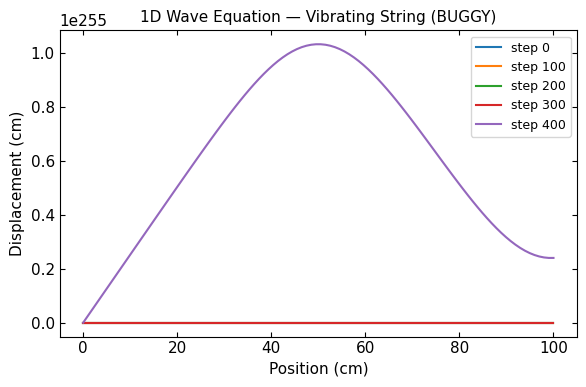

In [7]:
# ============================================================
# DEBUGGING CHALLENGE — BUGGY CODE
# DO NOT FIX THIS CELL — copy it and fix in a new cell below
# ============================================================

def wave_equation_step(
    u: np.ndarray,
    u_old: np.ndarray,
    c: float,
    dx: float,
    dt: float
) -> float:                                              # BUG somewhere in this function
    """Advance the 1D wave equation by one time step.

    Uses the central difference scheme:
    u_new[i] = 2*u[i] - u_old[i] + C^2*(u[i+1] - 2*u[i] + u[i-1])
    where C = c*dt/dx is the Courant number.

    Parameters
    ----------
    u : np.ndarray
        Current displacement profile. Shape (N,).
    u_old : np.ndarray
        Previous displacement profile. Shape (N,).
    c : float
        Wave speed (m/s).
    dx : float
        Spatial grid spacing (m).
    dt : float
        Time step (s).

    Returns
    -------
    np.ndarray
        Next displacement profile. Shape (N,).
    """
    C2 = (c * dt / dx)**2

    # CFL stability check
    if c * dt / dx < 1.0:                                # BUG somewhere near here
        print("Warning: CFL condition violated! Solution may be unstable.")

    u_new = np.zeros_like(u)

    # Interior points: finite difference update
    for i in range(1, len(u) - 1):
        u_new[i] = 2*u[i] - u_old[i] + C2 * (u[i+1] + 2*u[i] + u[i-1])  # BUG somewhere here

    # Boundary conditions: fixed ends
    u_new[0] = 0.0                                       # Left end fixed
    u_new[-1] = u_new[-2]                                # BUG somewhere here

    return u_new


# --- Run the buggy solver ---
L = 1.0         # string length (m)
c = 100.0       # wave speed (m/s)
N = 100         # grid points
dx = L / (N - 1)
dt = 0.8 * dx / c   # Courant number = 0.8

x = np.linspace(0, L, N)

# Initial condition: plucked string (triangle)
u = np.where(x < 0.5, 2*x, 2*(1-x)) * 0.01   # max displacement 1 cm
u_old = u.copy()  # start from rest (first-order approximation)

# Time stepping
fig, ax = plt.subplots()
n_steps = 500
for step in range(n_steps):
    u_new = wave_equation_step(u, u_old, c, dx, dt)
    u_old = u
    u = u_new
    if step % 100 == 0:
        ax.plot(x * 100, u * 100, label=f'step {step}')

ax.set_xlabel('Position (cm)')
ax.set_ylabel('Displacement (cm)')
ax.set_title('1D Wave Equation — Vibrating String (BUGGY)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Tasks

**Task D.1 (4 points):** Read the buggy code above carefully. List **all 4 errors** you can find in a markdown cell. For each bug, explain:
- What the error is
- Why it's wrong (what physics or coding principle it violates)
- What the correct version should be

**Task D.2 (4 points):** Fix all the bugs in a new code cell below. Run the corrected solver and verify it produces a physically reasonable result — the string should oscillate back and forth, not blow up or drift. All functions must have correct type annotations.

**Task D.3 (2 points):** Create a plot of your corrected solution showing the string at several time steps. Does the behavior match what you expect for a plucked string? Briefly explain.

In [8]:
# Your corrected code here


## Submission: Fork Workflow & AI Code Review (10 points)

### Fork Workflow (8 points)

1. **Fork** the repository to `github.com/yourname/PHY386` (if not done already)

2. **Make sure you're on your branch** (`yourname-hw4`)

3. **Commit your work** with descriptive messages:
   - Good: `Implement sparse Laplace solver with boundary conditions`
   - Good: `Add electric field quiver plot with RdBu colormap`
   - Good: `Fix wave equation bugs with corrected finite difference stencil`
   - Bad: `update`, `fix`, `stuff`, `done`

4. **Push to your fork**:
   ```
   git push origin yourname-hw4
   ```

5. **Open a Pull Request**:
   - Go to `github.com/yourname/PHY386`
   - Click **"Compare & pull request"** (or Pull requests → New)
   - **Important**: Set base repository to `ubsuny/PHY386` and base branch to `Homework2026`
   - Set compare to your branch `yourname-hw4`
   - Title: `HW4 - 2026 - yourusername`

6. **Fill out the PR template** (it loads automatically):
   - Check the appropriate boxes
   - Add label: `homework-in-progress` or `homework-final`
   - Assign reviewer: `@laserlab`
   - Set milestone: `HW4-2026`

### AI Code Review (2 points)

7. **Request AI Code Review from GitHub Copilot**:
   - In the **Reviewers** section of your PR, add **`@copilot`** as a reviewer
   - Copilot will automatically review your code and leave inline comments
   - It checks for type annotation issues, physics mistakes, plotting standards, and code quality

8. **Respond to Copilot's review**:
   - Read each comment Copilot leaves on your PR
   - For each comment, either:
     - **Fix the issue** and push a new commit, OR
     - **Reply explaining why you disagree** (Copilot isn't always right!)
   - Leave a summary comment on your PR: what Copilot caught, what was useful, and what was wrong or unhelpful
   - This teaches a critical skill: **AI review is a tool, not an authority** — you must evaluate its feedback

---

### Checklist

- [ ] Forked the repository and synced with upstream
- [ ] Created branch `yourname-hw4` from `Homework2026`
- [ ] Completed **one** PDE problem (A, B, or C) with all subtasks
- [ ] All functions have **type annotations** and **docstrings**
- [ ] All plots have labeled axes with units, titles, and legends where appropriate
- [ ] Completed the debugging challenge (Tasks D.1–D.3)
- [ ] All commit messages are descriptive
- [ ] PR opened with correct title, label, reviewer, and milestone
- [ ] Requested `@copilot` as a reviewer
- [ ] Responded to Copilot's review comments with fixes or explanations

## Resources

- [Python Type Hints Cheat Sheet (mypy)](https://mypy.readthedocs.io/en/stable/cheat_sheet_py3.html)
- [scipy.integrate.solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)
- [scipy.integrate.solve_bvp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_bvp.html)
- [scipy.sparse.linalg.spsolve](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.spsolve.html)
- [Finite Difference Method — Wikipedia](https://en.wikipedia.org/wiki/Finite_difference_method)
- [Matplotlib contour](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html) and [quiver](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.quiver.html)
- [GitHub Codespaces Documentation](https://docs.github.com/en/codespaces)
- [GitHub Forking Workflow](https://docs.github.com/en/pull-requests/collaborating-with-pull-requests/working-with-forks)
- [Griffiths, Introduction to Electrodynamics, Ch. 3](https://en.wikipedia.org/wiki/Introduction_to_Electrodynamics) (Laplace equation)
- [Euler-Bernoulli Beam Theory](https://en.wikipedia.org/wiki/Euler%E2%80%93Bernoulli_beam_theory)